In [2]:
%pip install numpy==2.0.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split the data into train and test sets
from sklearn.model_selection import train_test_split

# to build a linear regression model
from sklearn.linear_model import LinearRegression

# to check a regression model's performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv('insurance.csv')

df_copy = df

In [6]:
df.shape

(1338, 7)

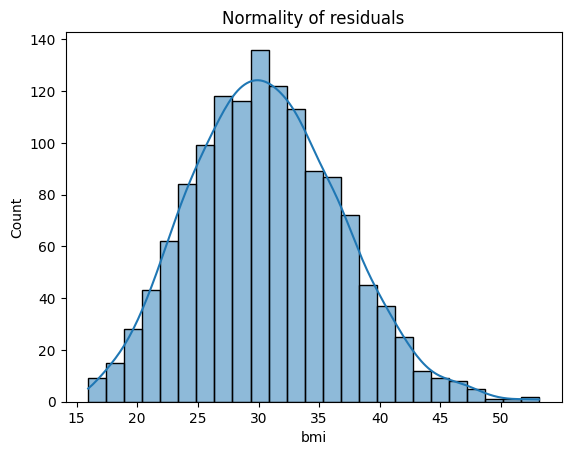

In [7]:
sns.histplot(df_copy["bmi"], kde=True)
plt.title("Normality of residuals")
plt.show()

In [8]:
# The customers from which region has the highest median insurance charge?
df_copy.groupby("region")["charges"].median().sort_values(ascending=False)

region
northeast    10057.652025
southeast     9294.131950
northwest     8965.795750
southwest     8798.593000
Name: charges, dtype: float64

In [11]:
# What is the correlation between age and charges?
df_copy["age"].corr(df_copy["charges"])

np.float64(0.2990081933306476)

In [13]:
# Create dummy variables for the categorical columns using pd.get_dummies() with drop_first=True. A dummy variable is dropped for which of the following regions?
df_with_dummies = pd.get_dummies(df_copy, drop_first=True)
df_with_dummies.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [19]:
# Drop the column containing the log-transformed values of bmi. 
# Split the data in a 70:30 ratio to obtain the train and test sets. How many rows are there in the test set?
# Note: Use random_state=1. Do not treat the outliers in the data.
df_no_log_bmi = df_with_dummies.drop(columns=['bmi'])
X_train, X_test, y_train, y_test = train_test_split(df_no_log_bmi.drop(columns=['charges']), 
                                                df_no_log_bmi['charges'], 
                                                test_size=0.3, 
                                                random_state=1)
X_test.shape[0]

402

In [20]:
# Build a linear regression model using the train set. Which of the following is true regarding the intercept?
model = LinearRegression()
model.fit(X_train, y_train)
model.intercept_

np.float64(-2433.3094677002755)

In [21]:
# Which of the following is true regarding the R-squared of the model on the train dataset?
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.7310971783115152

In [25]:
# Which of the following is true regarding the RMSE on the test set? 
# y_test_pred = model.predict(X_test)
# rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
# rmse_test
pred_test = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
rmse

np.float64(6443.536614539605)

In [23]:
# Which of the following is true for the MAE on the test set?
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

4080.1566858558476